# TMC1 筛选流程与结果核对

依次运行以下单元，查看真实输入、执行小样本训练和规则设计、核对正式六候选，并离线重建 A1—A3 补充表。

**两类结果分开阅读**：7 项规则设计结果用于演示流程；正式六候选来自已完成的筛选。两条单轮生成支路的结果按本次实跑显示，不替换正式候选名单。

先按根目录 `requirements.txt` 安装科学依赖，再安装 `notebooks/requirements-notebook.txt`。用同一环境打开本文件并选择“全部运行”。从代码根目录或 `notebooks` 目录启动均可。输出写到代码包外的独立运行目录。

In [1]:
from pathlib import Path
import csv, json, subprocess, sys, time, hashlib, html, re
from datetime import datetime, timezone
from IPython.display import display, HTML

ROOT = next(p for p in (Path.cwd(), Path.cwd().parent) if (p / 'make_results.py').is_file())
SUPPLEMENT = ROOT / 'data' / 'group_supplement'
RUN_ID = datetime.now(timezone.utc).strftime('%Y%m%dT%H%M%SZ')
OUT = ROOT.parent / 'notebook_outputs' / RUN_ID
OUT.mkdir(parents=True, exist_ok=False)
JOBS = []
def read_csv(path):
    with path.open(encoding='utf-8-sig', newline='') as f:
        return list(csv.DictReader(f))
def sha(path):
    return hashlib.sha256(path.read_bytes()).hexdigest()
def clean(text):
    for p, name in ((OUT, '../notebook_outputs/' + RUN_ID), (ROOT, 'TMC1_code'), (Path(sys.prefix), 'python_environment')):
        text = text.replace(str(p), name).replace(str(p).replace('\\', '/'), name)
    return text
def run(args, label, echo=True):
    started = time.perf_counter()
    p = subprocess.run([sys.executable, '-u', '-B', *args], cwd=ROOT, text=True, encoding='utf-8', capture_output=True)
    log = clean(p.stdout + p.stderr)
    (OUT / (label + '.log')).write_text(log, encoding='utf-8')
    JOBS.append({'entry': args[0], 'arguments': args[1:], 'exit_code': p.returncode, 'seconds': round(time.perf_counter()-started, 3)})
    if echo:
        print(log)
    assert p.returncode == 0, label + ' failed; inspect its saved log.'
    return p.stdout
def show_table(rows, fields):
    body = '<tr>' + ''.join('<th>' + html.escape(title) + '</th>' for key,title in fields) + '</tr>'
    for row in rows:
        body += '<tr>' + ''.join('<td>' + html.escape(str(row[key])) + '</td>' for key,title in fields) + '</tr>'
    display(HTML('<style>td,th{padding:8px 12px;text-align:left;border-bottom:1px solid #ddd}</style><table>'+body+'</table>'))
print('环境已就绪：Python', sys.version.split()[0])
print('所有输出保存在包外独立目录，原始代码与冻结结果不改写。')

环境已就绪：Python 3.12.10
所有输出保存在包外独立目录，原始代码与冻结结果不改写。


## 1　读取本次输入

代码包自带 2048 条公开化合物记录。下表直接读取文件，不手工填写示例值。

In [2]:
inputs = read_csv(ROOT / 'data' / 'tutorial_library2048.csv')
assert len(inputs) == 2048
print('小样本输入记录：', len(inputs))
show_table(inputs[:5], [('compound_id','化合物编号'),('source_id','来源编号'),('mw','分子量')])
input_hash = sha(ROOT / 'data' / 'tutorial_library2048.csv')

小样本输入记录： 2048


化合物编号,来源编号,分子量
LIB_AABWNUVUEHGWFW,CHEMBL1079739,487.577
LIB_AACCKHROFFBPIY,CHEMBL102611,487.578
LIB_AACJHFPFYOSUIH,CHEMBL100149,412.505
LIB_AACWENFRCBQJKI,CHEMBL1079156,428.522
LIB_AAEBDTFRJJEIJL,CHEMBL1082160,465.922


## 2　执行小样本训练与规则设计

调用现有 `run_example.py`。两条生成支路各训练 1 轮，另行运行规则设计示例。训练记录和失败样本保存在本次输出目录。

In [3]:
example_rel = '../notebook_outputs/' + RUN_ID + '/example'
run(['run_example.py', '--train-small', '--output', example_rel], 'small_example')
example = read_csv(OUT / 'example' / 'example_screening.csv')
print('本次规则设计示例数：', len(example))
show_table(example, [('example_rank','序号'),('compound_id','规则设计编号'),('parent_id','亲本编号'),('mw','分子量')])
training = []
for index, name in ((1,'SMILES'), (2,'SELFIES')):
    records = []
    for line in (OUT / 'example' / ('step' + str(index) + '.log')).read_text('utf-8').splitlines():
        try:
            records.append(json.loads(line))
        except json.JSONDecodeError:
            pass
    last = records[-1]
    eligible = last['unique_eligible'] if index == 1 else last['base_result']['eligible']
    training.append({'route':name,'eligible':eligible})
show_table(training, [('route','单轮训练路线'),('eligible','本次合格生成物数')])

Example completed: actual rule design -> property/alert selection -> illustrative screening 7 designs

本次规则设计示例数： 7


序号,规则设计编号,亲本编号,分子量
1,DES_YAZKHWIVYWHKHW,LIB_CHEMBL2103870,451.429
2,DES_JMWNSKZCTCNWSL,LIB_CHEMBL2103870,465.456
3,DES_AFGHMHSPPSRMJL,LIB_CHEMBL2103870,495.482
4,DES_LYIDGSVTVBVLGU,LIB_CHEMBL3894860,460.586
5,DES_TWTKMJWAXOPXSX,LIB_CHEMBL3894860,432.532
6,DES_FBGMOLGYPGIRPG,LIB_CHEMBL3894860,474.569
7,DES_JWEMMDYMRYGOAJ,LIB_CHEMBL3894860,476.585


单轮训练路线,本次合格生成物数
SMILES,0
SELFIES,0


## 3　核对正式六候选

现有 `make_results.py` 从冻结证据中重新核对候选和统计。它不在这段演示里重新执行全量分子对接，也不把小样本的 7 项规则示例写进正式名单。

In [4]:
formal_rel = '../notebook_outputs/' + RUN_ID + '/formal/results.csv'
run(['make_results.py', '--output', formal_rel], 'formal_results')
formal = read_csv(OUT / 'formal' / 'results.csv')
assert len(formal) == 6
assert sha(OUT / 'formal' / 'results.csv') == sha(ROOT / 'results.csv')
show_table(formal, [('candidate_id','正式候选'),('source_id','ChEMBL编号'),('initial_vina_kcal_mol','Vina评分 kcal/mol'),('confirmation_QC_pass','四条件质量检查通过数'),('confirmation_middle_contact_pass','四条件目标区域接触数')])
print('正式六候选与包内冻结结果逐字节一致。')

Input integrity PASS: 205 bound files
R2 PASS: 360 attempts / 319 unique physical jobs / 120 per arm
MW >= 350 PASS: Random 35/81; Ridge 86/120; AI 115/120
Confirmation PASS: 6 candidates x 4 conditions; QC 24/24; Middle 22/24
Candidate list PASS: 6 verified identities, SMILES, versions and ligand structures; original generation joint 0/40 retained
SUCCESS: 6-candidate results.csv and separate summary_metrics.csv written; SHA256 478e0d624b158ef5e42a454ea412e3ca392fa694af1556a3d48587e6b170908c
{"status": "PASS", "bound_R3_source_files_verified": 656, "diagnostic_rows": 9098, "all_failures_retained": true, "six_candidates_alert_free": true, "static_matrix": 24, "raw_jobs": 26, "ANM_networks": 6, "ANM_traversals": 24, "full_atom_dynamic_receptors": 0, "generation_top10": 10, "results_csv_sha256": "478e0d624b158ef5e42a454ea412e3ca392fa694af1556a3d48587e6b170908c", "r3_summary_sha256": "b4dde2f294b261a7cf7585593544ef78d8e04dc7413dcfb472175a6973f64403", "scope": "existing frozen calculation 

正式候选,ChEMBL编号,Vina评分 kcal/mol,四条件质量检查通过数,四条件目标区域接触数
LIB_YWDIXVZCRMMQQY,CHEMBL1079964,-10.075,4,4
LIB_MYAFDHCCQBIZLC,CHEMBL1080362,-10.066,4,3
LIB_ZNDXPRCORYDEAP,CHEMBL1081740,-10.049,4,4
LIB_FCRHJSNRFAAYQD,CHEMBL1080669,-10.019,4,4
LIB_DNDVGFIEWOHGAH,CHEMBL1076497,-9.934,4,4
LIB_ZVHBDYFMHCQADD,CHEMBL1080205,-9.914,4,3


正式六候选与包内冻结结果逐字节一致。


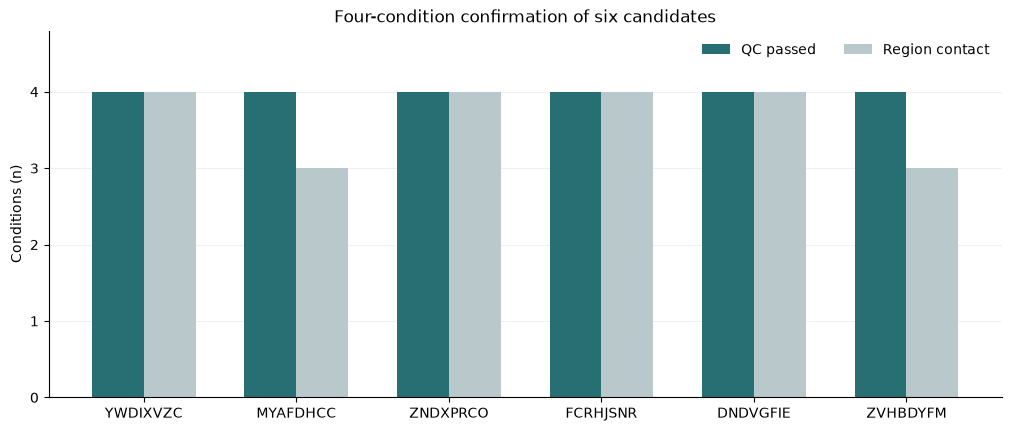

In [5]:
import matplotlib.pyplot as plt
import numpy as np
x = np.arange(len(formal))
fig, ax = plt.subplots(figsize=(10, 4.2), constrained_layout=True)
ax.bar(x-.17, [int(r['confirmation_QC_pass']) for r in formal], .34, label='QC passed', color='#276F73')
ax.bar(x+.17, [int(r['confirmation_middle_contact_pass']) for r in formal], .34, label='Region contact', color='#B8C8CB')
ax.set(xticks=x, xticklabels=[r['candidate_id'].removeprefix('LIB_')[:8] for r in formal], yticks=range(5), ylim=(0,4.8), ylabel='Conditions (n)', title='Four-condition confirmation of six candidates')
ax.spines[['top','right']].set_visible(False)
ax.legend(frameon=False, loc='upper right', ncols=2)
ax.grid(axis='y', alpha=.18);ax.set_axisbelow(True)
fig.savefig(OUT / 'six_candidate_confirmation.png', dpi=180)
display(fig)
plt.close(fig)

图中每个候选的分母均为 **4 次条件确认**。质量检查与目标区域接触分别统计；这些计算证据尚不能确定通道功能作用。

## 4　检查并离线重建 A1—A3

先检查补充目录清单、分子身份和范围异常，再调用现有离线重建入口。使用已保存的官方响应和预测文件；此单元不重新请求网页、不重新训练 ADMET 模型。

In [6]:
verification = json.loads(run(['data/group_supplement/verify_science_supplement.py'], 'supplement_verify', echo=False))
print('补充证据检查：', verification['passed'], '通过；', verification['failed'], '失败')
rebuilt_rel = '../notebook_outputs/' + RUN_ID + '/supplement_rebuilt'
run(['data/group_supplement/rebuild_science_tables.py', '--output', rebuilt_rel], 'supplement_rebuild')
rebuilt_receipt = json.loads((OUT / 'supplement_rebuilt' / 'OFFLINE_REBUILD_RECEIPT.json').read_text('utf-8'))
assert rebuilt_receipt['status'] == 'PASS'
show_table(rebuilt_receipt['comparisons'], [('table','重建表'),('rows','行数'),('differing_shared_fields','与原表不同的共享字段数')])

补充证据检查： 617 通过； 0 失败


{"status": "PASS", "mode": "offline_saved_primary_responses_and_predictions", "comparisons": [{"table": "pharmacology_actual_activity_records.csv", "rows": 622, "differing_shared_fields": 0}, {"table": "two_threshold_neighbors_rebuilt.csv", "rows": 1458, "differing_shared_fields": 0}, {"table": "multiparameter_druglikeness_rebuilt.csv", "rows": 11, "differing_shared_fields": 0}, {"table": "formal6_training12_overlap_rebuilt.csv", "rows": 6, "differing_shared_fields": 0}], "not_new_docking_or_ADMET_model_training": true}



重建表,行数,与原表不同的共享字段数
pharmacology_actual_activity_records.csv,622,0
two_threshold_neighbors_rebuilt.csv,1458,0
multiparameter_druglikeness_rebuilt.csv,11,0
formal6_training12_overlap_rebuilt.csv,6,0


In [7]:
neighbors = read_csv(OUT / 'supplement_rebuilt' / 'two_threshold_neighbors_rebuilt.csv')
properties = read_csv(OUT / 'supplement_rebuilt' / 'multiparameter_druglikeness_rebuilt.csv')
anomalies = read_csv(SUPPLEMENT / 'A3_ADMET_SA' / 'ADMET_AI_v2_out_of_range.csv')
print('类似物配对：', len(neighbors), '；相似度≥0.6：', sum(float(r['official_tanimoto']) >= .6 for r in neighbors))
print('成药性预测/SA分子数：', len(properties), '；保留的 ADMET-AI 范围异常：', len(anomalies))
show_table(properties, [('id','分子编号'),('SwissADME_GI absorption','SwissADME胃肠吸收预测'),('SwissADME_BBB permeant','SwissADME BBB预测'),('SwissADME_Synthetic Accessibility','SwissADME SA'),('RDKit_SA_score','RDKit SA')])

类似物配对： 1458 ；相似度≥0.6： 276
成药性预测/SA分子数： 11 ；保留的 ADMET-AI 范围异常： 10


分子编号,SwissADME胃肠吸收预测,SwissADME BBB预测,SwissADME SA,RDKit SA
LIB_YWDIXVZCRMMQQY,Low,No,3.71,2.4241605118301663
LIB_MYAFDHCCQBIZLC,Low,No,3.63,2.450496585166068
LIB_ZNDXPRCORYDEAP,Low,No,3.61,2.6773814150166757
LIB_FCRHJSNRFAAYQD,Low,No,3.93,2.542591185079049
LIB_DNDVGFIEWOHGAH,High,No,3.95,2.665172536538952
LIB_ZVHBDYFMHCQADD,Low,No,3.63,2.580473148789359
LIB_CHEMBL2103870,High,No,3.28,2.7563124500803955
LIB_CHEMBL3894860,High,No,4.11,3.526180912510976
DES_JMWNSKZCTCNWSL,High,No,3.42,2.7899093515323283
GEN_LDAGBLZIWYMUFJ,High,No,2.95,2.4338764875085257


### 补充结果的解释

- **A1**：已核对作者 12 个独立训练结构，六候选与其标准化母体交集为 0。68 个独立阻断剂的完整来源未建立，不能把有限对照写成全面查新。
- **A2**：保存两档相似性配对及代表分子的原始药理记录。相似结构和既有药理可用于解释候选，不等于已证实 TMC1 疗效。
- **A3**：11 个分子的 SwissADME 返回结构均已核对；ADMET-AI 保留 10 个超范围输出。两种 SA 实现分别显示，不混用。ADMETlab 请求本次未成功。BBB 预测也不等同于血迷路屏障通透性。

## 5　保存本次执行回执

In [8]:
receipt = {
    'status':'PASS', 'python':sys.version.split()[0], 'jobs':JOBS,
    'input_rows':len(inputs), 'example_rule_rows':len(example), 'formal_rows':len(formal),
    'tutorial_vs_formal_separate':True, 'formal_results_sha256':sha(OUT/'formal/results.csv'),
    'tutorial_input_sha256':input_hash, 'supplement_manifest_sha256':sha(SUPPLEMENT/'FILE_MANIFEST.json'),
    'core_entry_sha256':{n:sha(ROOT/n) for n in ['run_example.py','make_results.py','make_results_r2.py','verify_r3_evidence.py']},
    'supplement_checks_passed':verification['passed'], 'offline_rebuild':rebuilt_receipt,
    'ADMET_AI_out_of_range_retained':len(anomalies), 'all_outputs_outside_code_package':True
}
(OUT/'NOTEBOOK_EXECUTION_RECEIPT.json').write_text(json.dumps(receipt, ensure_ascii=False, indent=2), encoding='utf-8')
print('全部单元执行完成；四个现有入口均成功，正式候选结果与冻结值一致。')
print('输出包括示例表、正式结果、确认图、补充重建表和执行回执。')

全部单元执行完成；四个现有入口均成功，正式候选结果与冻结值一致。
输出包括示例表、正式结果、确认图、补充重建表和执行回执。
